# Fase 1: Geração Amostras

Gera novas amostras de estados do tabuleiro 4x3 usando o algoritmo **DAC - Diversidade Adaptativa em Cascata**.

Um estado do tabuleiro é a representação dos traços, pontos e caixas fechadas no jogo dos pontinhos (ver imagem abaixo).

Dois Minimax de diferentes profundidades jogam partidas do jogo dos pontinhos no tabuleiro 4x3 do começo até  final da partida. Cada estado do tabuleiro é salvo.

Definição da melhor jogada para cada um destes estados de tabuleiro ocorre na Fase 3.

## Representação visual de um estado de tabuleiro

**Obs:** A aresta de melhor jogada (verde) ainda não compõe o estado da matriz crua. Ela entra na fase3 no campo `melhor_jogada` e `score_melhor_jogada`. Ela é o alvo do treinamento da nossa Rede Neural Convolucional.

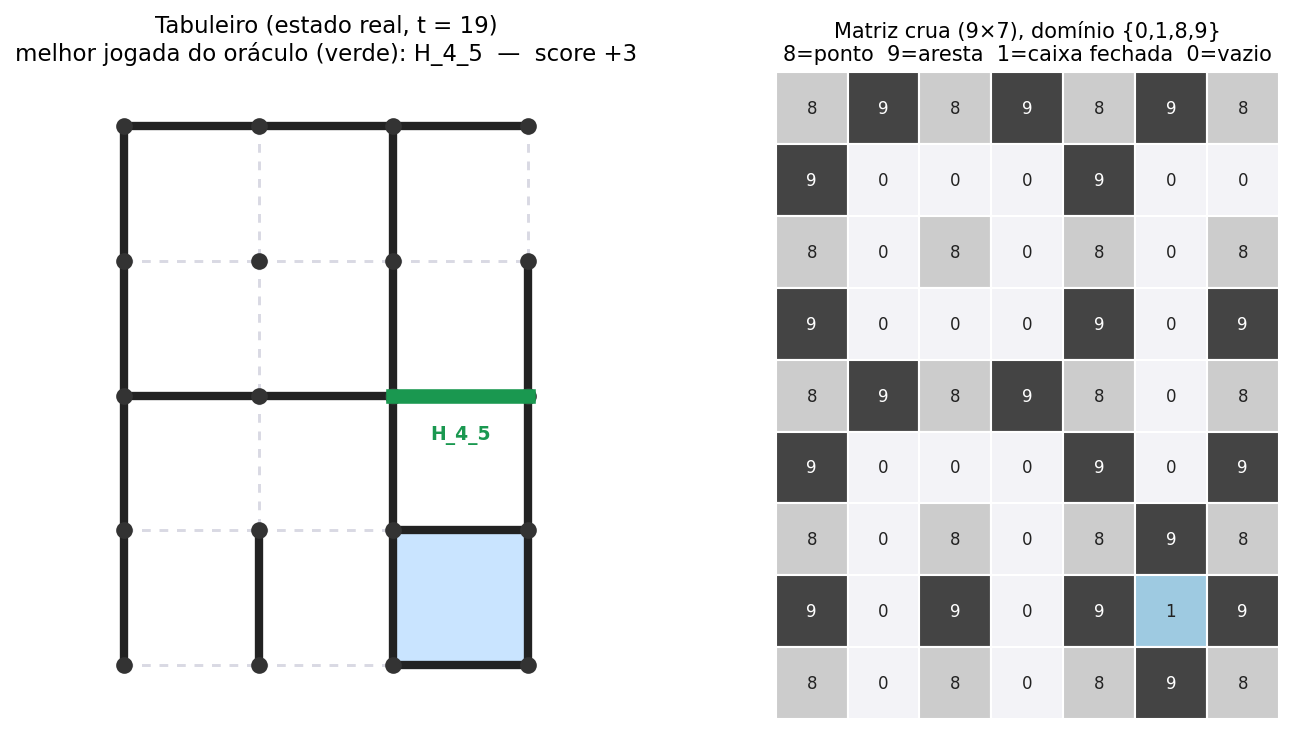

## Fluxo

**Fase 1 (este notebook)**
* Joga partidas do jogo dos pontinhos do início ao fim
* Cada estado (turno) é salvo no NPZ

Fase 2  (fase2_enriquecimento.ipynb)
* adiciona canais (N,4,3,12) + 3 escalares parâmetros relacionados a cadeias

Fase 3  (fase3_score_melhor_jogada.ipynb)
* computa melhor_jogada / score_melhor_jogada

Fase 4  (fase4_augmentacao_simetria.ipynb)
* gera 3 variantes por NPZ (_refH, _refV, _r180)
* 4× o número de amostras de treino


## Formato dos dados gerados

| Campo | Shape | Dtype | Descrição |
|---|---|---|---|
| `estados` | `(N, 9, 7)` | `int8` | Matriz crua `{0,1,8,9}` |
| `qtd_tracos` | `(N,)` | `int8` | Traços aplicados (1-30) |
| `score_jogada` | `(N, 31)` | `float32` | Q-values com score das jogadas que levaram a geração do estado do tabuleiro - não é utilizada no treinamento |
| `depth_jogada` | `(N,)` | `int8` | Profundidade do Minimax usada em score_jogada |
| `depth_geracao` | `(N,)` | `int8` | Profundidade do Minimax do estado anterior |
| `melhor_jogada` | `(N,)` | `U5` | `''` (campo vazio a ser preenchido na Fase 3) |
| `score_melhor_jogada` | `(N, 31)` | `float32` | `-1e9` (campo vazio a ser preenchido na Fase 3) |
| `depth_melhor_jogada` | `(N,)` | `int8` | `0` (campo vazio a ser preenchido na Fase 3) |
| `labels_canonicos` | `(31,)` | `U5` | Labels das arestas no tabuleiro 4x3 |

**Diretório de saída**: `'dados/base_adaptativo_limpa'`

**Retomada**: Re-executar continua de onde parou, sem perder dados.

In [ ]:
import os
import sys
import time
import concurrent
import multiprocessing as mp
from collections import Counter
from pathlib import Path

import numpy as np

ROOT = Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from gerador_amostras_pontinhos import (
    jogar_partida_completa,
    LABELS_CANONICOS,
    N_LABELS,
    ALTURA,
    LARGURA,
    SCORE_INDISPONIVEL,
    DEPTH_NAO_CALCULADO,
    ESTADOS_POR_PARTIDA,
)

print(f'ROOT              = {ROOT}')
print(f'N_LABELS          = {N_LABELS}')
print(f'ALTURA x LARGURA  = {ALTURA} x {LARGURA}')
print(f'ESTADOS_POR_PARTIDA = {ESTADOS_POR_PARTIDA}')

ROOT              = D:\Desenvolvimento\arena-sagaz\arena-sagaz-backend
N_LABELS          = 31
ALTURA x LARGURA  = 9 x 7
ESTADOS_POR_PARTIDA = 30


## Configuração

Parâmetro `ALVO_DISTINTOS` indica quantas amostras do tabuleiro preenchido devem ser geradas. Ao chegar neste número a partidas automáticas são interrompidas e o processo finalizado.

In [ ]:
# Meta global de estados distintos
ALVO_DISTINTOS = 2_000_000          # gera até atingir este total

# Parâmetros fixos
TAMANHO_LOTE = 10_000                # qtd. total de estados por NPZ
SEED_GLOBAL  = 202605221117          # seed desta rodada - deve ser alterado a cada inicialização da rotina

# Paralelismo
NUM_WORKERS = max(1, mp.cpu_count() - 2)
QUEUE_DEPTH = NUM_WORKERS * 4

# Diretório
OUTPUT_DIR = ROOT / 'dados' / 'base_limpa'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'OUTPUT_DIR    = {OUTPUT_DIR}')
print(f'NUM_WORKERS   = {NUM_WORKERS}')
print(f'ALVO_DISTINTOS = {ALVO_DISTINTOS:,}')

OUTPUT_DIR    = D:\Desenvolvimento\arena-sagaz\arena-sagaz-backend\dados\base_adaptativo_limpa
NUM_WORKERS   = 14
ALVO_DISTINTOS = 2,000,000


## Recuperação do estado existente

Lê todos os NPZs do diretório para:
- Reconstruir o **set global de hashes** (evita duplicatas).
- Determinar o **índice do próximo NPZ** (retomada idempotente).

NPZs com `melhor_jogada` preenchida (originais) são incluídos no conteo de
hashes mas **não são re-escritos**, apenas os novos recebem schema v2-f1.

In [3]:
SUFIXOS_SIMETRIA = ('_refH', '_refV', '_r180')

def _e_original(path: Path) -> bool:
    return not any(path.stem.endswith(s) for s in SUFIXOS_SIMETRIA)


def reconstruir_estado_global(output_dir: Path):
    """Lê todos os NPZs originais e devolve (hashes_set, ultimo_idx)."""
    hashes: set[bytes] = set()
    npzs = [p for p in sorted(output_dir.glob('dataset_pequeno_*.npz')) if _e_original(p)]
    for path in npzs:
        try:
            with np.load(path, allow_pickle=False) as d:
                estados = d['estados']
            for i in range(estados.shape[0]):
                hashes.add(estados[i].tobytes())
        except Exception as e:
            print(f'[WARN] NPZ ignorado: {path.name} ({e})')

    ultimo_idx = 0
    if npzs:
        try:
            ultimo_idx = int(npzs[-1].stem.split('_')[-1])
        except ValueError:
            ultimo_idx = len(npzs)

    return hashes, ultimo_idx


print('Reconstruindo estado global (pode levar alguns minutos)...')
t_start = time.time()
HASHES_GLOBAIS, ULTIMO_NPZ_IDX = reconstruir_estado_global(OUTPUT_DIR)
print(f'Concluído em {time.time() - t_start:.1f}s.')
print()
n_npzs_orig = len([p for p in sorted(OUTPUT_DIR.glob('dataset_pequeno_*.npz')) if _e_original(p)])
print(f'NPZs originais existentes : {n_npzs_orig}')
print(f'Estados distintos já gerados: {len(HASHES_GLOBAIS):,}')
print(f'Último índice NPZ         : {ULTIMO_NPZ_IDX}')
print(f'Restantes para a meta     : {max(0, ALVO_DISTINTOS - len(HASHES_GLOBAIS)):,}')

if len(HASHES_GLOBAIS) >= ALVO_DISTINTOS:
    print()
    print(f'Meta já atingida ({len(HASHES_GLOBAIS):,} ≥ {ALVO_DISTINTOS:,}). '
          'Aumente ALVO_DISTINTOS para gerar mais amostras.')

Reconstruindo estado global (pode levar alguns minutos)...
Concluído em 1.1s.

NPZs originais existentes : 336
Estados distintos já gerados: 1,543,614
Último índice NPZ         : 336
Restantes para a meta     : 456,386


## Fase 1 - Geração via DAC

Como a geração dos milhões de dados utilizando Minimax, que é um processo pesado, realizamos a geração em paralelo utilizando os vários núcleos do processador.

Cada worker joga uma partida completa (tabuleiro vazio até o estado terminal) e retorna 30 "retratos" (um por t de 1 a 30). O loop principal:

1. Mantém `QUEUE_DEPTH` partidas em paralelo.
2. Para cada partida: acumula 30 snapshots no buffer, atualiza hashes.
3. A cada `TAMANHO_LOTE` snapshots: grava NPZ atomicamente.
4. Para ao atingir `ALVO_DISTINTOS` estados distintos.

**Campos `melhor_jogada` / `score_melhor_jogada` / `depth_melhor_jogada`** são preenchidos com valores padrão (`''`, `-1e9`, `0`) e serão apurados definitivamente na faase 3.

In [ ]:
def salvar_npz_fase1(buffer: list, idx_npz: int) -> Path:
    """Grava NPZ v2-f1 com sentinelas nos campos de Fase 3. Sobrescrita atômica."""
    n = len(buffer)
    estados_arr          = np.empty((n, ALTURA, LARGURA), dtype=np.int8)
    qtd_tracos_arr       = np.empty(n, dtype=np.int8)
    score_jogada_arr     = np.empty((n, N_LABELS), dtype=np.float32)
    depth_jogada_arr     = np.empty(n, dtype=np.int8)
    depth_geracao_arr    = np.empty(n, dtype=np.int8)

    for i, (mb, qt, sj, dj, dg) in enumerate(buffer):
        estados_arr[i]      = np.frombuffer(mb, dtype=np.int8).reshape(ALTURA, LARGURA)
        qtd_tracos_arr[i]   = qt
        score_jogada_arr[i] = np.frombuffer(sj, dtype=np.float32)
        depth_jogada_arr[i] = dj
        depth_geracao_arr[i]= dg

    # Sentinelas, preenchidos na fase 3 (rotulacao pelo oraculo)
    melhor_jogada_arr       = np.empty(n, dtype='<U5')
    melhor_jogada_arr[:]    = ''
    score_melhor_jogada_arr = np.full((n, N_LABELS), SCORE_INDISPONIVEL, dtype=np.float32)
    depth_melhor_jogada_arr = np.full(n, DEPTH_NAO_CALCULADO, dtype=np.int8)
    labels_arr              = np.array(LABELS_CANONICOS, dtype='<U5')

    nome    = f'dataset_pequeno_{idx_npz:04d}.npz'
    caminho = OUTPUT_DIR / nome
    tmp     = caminho.with_name(caminho.stem + '.tmp.npz')
    np.savez_compressed(
        tmp,
        estados=estados_arr,
        qtd_tracos=qtd_tracos_arr,
        score_jogada=score_jogada_arr,
        depth_jogada=depth_jogada_arr,
        depth_geracao=depth_geracao_arr,
        melhor_jogada=melhor_jogada_arr,
        score_melhor_jogada=score_melhor_jogada_arr,
        depth_melhor_jogada=depth_melhor_jogada_arr,
        labels_canonicos=labels_arr,
    )
    os.replace(tmp, caminho)
    return caminho


def fase1_gerar(hashes_globais: set, ultimo_idx: int) -> int:
    """Loop principal DAC. Retorna o último índice de NPZ gravado."""
    if len(hashes_globais) >= ALVO_DISTINTOS:
        print('Meta já atingida. Nada a fazer.')
        return ultimo_idx

    n_distintos_inicial = len(hashes_globais)
    rng_main   = np.random.default_rng(SEED_GLOBAL)
    buffer     = []
    npz_idx    = [ultimo_idx]
    n_partidas = 0

    def _flush():
        if len(buffer) >= TAMANHO_LOTE:
            npz_idx[0] += 1
            cam = salvar_npz_fase1(buffer[:TAMANHO_LOTE], npz_idx[0])
            del buffer[:TAMANHO_LOTE]
            return cam
        return None

    t0  = time.time()
    t_log = t0
    print(f'Fase 1: alvo={ALVO_DISTINTOS:,} | já={len(hashes_globais):,} | '
          f'workers={NUM_WORKERS} | queue={QUEUE_DEPTH}')

    with concurrent.futures.ProcessPoolExecutor(max_workers=NUM_WORKERS) as executor:
        futuros: dict = {}

        def _submeter():
            seed = int(rng_main.integers(0, 2**31 - 1))
            f = executor.submit(jogar_partida_completa, seed)
            futuros[f] = seed

        for _ in range(QUEUE_DEPTH):
            _submeter()

        while len(hashes_globais) < ALVO_DISTINTOS:
            done, _ = concurrent.futures.wait(
                list(futuros.keys()),
                return_when=concurrent.futures.FIRST_COMPLETED,
            )
            for f in done:
                futuros.pop(f)
                for snap in f.result():
                    hashes_globais.add(snap[0])  # snap[0] = estado_bytes
                    buffer.append(snap)
                n_partidas += 1
                cam = _flush()
                while cam is not None:
                    print(f'  NPZ salvo: {cam.name} | '
                          f'distintos={len(hashes_globais):,}/{ALVO_DISTINTOS:,} | '
                          f'partidas={n_partidas:,}')
                    cam = _flush()
                if len(hashes_globais) >= ALVO_DISTINTOS:
                    break
                _submeter()

            agora = time.time()
            if agora - t_log > 30:
                elapsed = agora - t0
                novos_rodada = len(hashes_globais) - n_distintos_inicial
                tx_d = novos_rodada / elapsed if elapsed > 0 else 0
                tx_p = n_partidas / elapsed if elapsed > 0 else 0
                rest = max(0, ALVO_DISTINTOS - len(hashes_globais))
                eta  = (rest / tx_d) if tx_d > 0 else float('inf')
                print(f'  partidas={n_partidas:,} ({tx_p:.1f}/s) | '
                      f'distintos={len(hashes_globais):,}/{ALVO_DISTINTOS:,} '
                      f'(+{novos_rodada:,} novos, {tx_d:.1f}/s) | ETA={eta/60:.1f} min')
                t_log = agora

        print(f'\nMeta atingida ({len(hashes_globais):,}). '
              f'Drenando {len(futuros)} partidas restantes...')
        for f in concurrent.futures.as_completed(list(futuros.keys())):
            for snap in f.result():
                hashes_globais.add(snap[0])
                buffer.append(snap)
            n_partidas += 1
            cam = _flush()
            while cam is not None:
                print(f'  NPZ (drain): {cam.name}')
                cam = _flush()
        futuros.clear()

    # Flush residual
    if buffer:
        npz_idx[0] += 1
        cam = salvar_npz_fase1(buffer, npz_idx[0])
        print(f'NPZ residual: {cam.name} ({len(buffer)} estados)')
        buffer.clear()

    elapsed = time.time() - t0
    print(f'\nFase 1 concluída em {elapsed/60:.1f} min.')
    print(f'  Partidas jogadas : {n_partidas:,}')
    print(f'  Estados gravados : ~{n_partidas * ESTADOS_POR_PARTIDA:,}')
    print(f'  Distintos totais : {len(hashes_globais):,}')
    print(f'  Último NPZ idx   : {npz_idx[0]}')
    return npz_idx[0]


ULTIMO_NPZ_IDX = fase1_gerar(HASHES_GLOBAIS, ULTIMO_NPZ_IDX)

Fase 1: alvo=2,000,000 | já=1,543,614 | workers=14 | queue=56
  partidas=38 (1.3/s) | distintos=1,544,261/2,000,000 (+647 novos, 21.3/s) | ETA=356.5 min
  partidas=78 (1.3/s) | distintos=1,544,947/2,000,000 (+1,333 novos, 22.0/s) | ETA=345.4 min
  partidas=126 (1.4/s) | distintos=1,545,783/2,000,000 (+2,169 novos, 23.9/s) | ETA=316.8 min
  partidas=175 (1.4/s) | distintos=1,546,632/2,000,000 (+3,018 novos, 25.0/s) | ETA=302.8 min
  partidas=223 (1.5/s) | distintos=1,547,432/2,000,000 (+3,818 novos, 25.3/s) | ETA=298.5 min
  partidas=268 (1.5/s) | distintos=1,548,191/2,000,000 (+4,577 novos, 25.2/s) | ETA=299.2 min
  partidas=307 (1.4/s) | distintos=1,548,840/2,000,000 (+5,226 novos, 24.6/s) | ETA=305.8 min
  NPZ salvo: dataset_pequeno_0337.npz | distintos=1,549,296/2,000,000 | partidas=334
  partidas=356 (1.5/s) | distintos=1,549,665/2,000,000 (+6,051 novos, 24.9/s) | ETA=301.3 min
  partidas=402 (1.5/s) | distintos=1,550,437/2,000,000 (+6,823 novos, 24.9/s) | ETA=300.9 min
  partidas=

## Auditoria pós-geração

Verifica os NPZs novos (com `melhor_jogada == ''`):
- Schema: campos obrigatórios presentes, shapes corretos.
- Domínio `{0, 1, 8, 9}` na matriz crua.
- Distribuição de `qtd_tracos` (deve ser bell-shaped).
- Nenhum `.tmp` residual.

In [5]:
import glob as _glob

npzs_novos = sorted([
    p for p in OUTPUT_DIR.glob('dataset_pequeno_*.npz')
    if _e_original(p)
])

tmps = list(OUTPUT_DIR.glob('*.tmp.npz'))
if tmps:
    print(f'AVISO: {len(tmps)} arquivo(s) .tmp residual(is):')
    for t in tmps:
        print(f'  {t.name}')

# Contar novos (sentinela: melhor_jogada == '')
n_novos = 0
n_existentes = 0
total_estados = 0
contador_t = Counter()
valores_dominio: set[int] = set()
erros = []

campos_v2f1 = {'estados', 'qtd_tracos', 'score_jogada', 'depth_jogada',
               'depth_geracao', 'melhor_jogada', 'score_melhor_jogada',
               'depth_melhor_jogada', 'labels_canonicos'}

for path in npzs_novos:
    with np.load(path, allow_pickle=False) as d:
        faltando = campos_v2f1 - set(d.files)
        if faltando:
            erros.append(f'{path.name}: campos ausentes {faltando}')
            continue
        n = d['estados'].shape[0]
        total_estados += n
        valores_dominio.update(int(v) for v in np.unique(d['estados']))
        for t in d['qtd_tracos']:
            contador_t[int(t)] += 1
        eh_novo = str(d['melhor_jogada'][0]) == ''
        if eh_novo:
            n_novos += 1
        else:
            n_existentes += 1

print(f'NPZs existentes (melhor_jogada preenchida): {n_existentes}')
print(f'NPZs novos      (melhor_jogada vazia):      {n_novos}')
print(f'Total NPZs originais                      : {len(npzs_novos)}')
print(f'Total estados                              : {total_estados:,}')
print(f'Domínio estados: {sorted(valores_dominio)}  (esperado: [0, 1, 8, 9])')

if erros:
    print(f'\nERROS:')
    for e in erros:
        print(f'  {e}')
elif not tmps:
    print('\nOK: schema v2-f1 válido em todos os NPZs. Nenhum .tmp residual.')

if n_novos > 0:
    print(f'\nDistribuição qtd_tracos (novos NPZs incluídos):')
    if contador_t:
        max_v = max(contador_t.values())
        for t in sorted(contador_t):
            bar = '#' * int(contador_t[t] * 40 / max_v)
            print(f'  t={t:>2}: {contador_t[t]:>7,} {bar}')

if n_novos > 0:
    print(f'\nPróximos passos:')
    print(f'  1. Execute fase2_enriquecimento_local.ipynb (adiciona canais + escalares).')
    print(f'  2. Execute fase3_rerotulacao_databricks.ipynb no Databricks (computa melhor_jogada).')
    print(f'  3. Execute fase4_augmentacao_simetria.ipynb (gera _refH/_refV/_r180).')

NPZs existentes (melhor_jogada preenchida): 0
NPZs novos      (melhor_jogada vazia):      419
Total NPZs originais                      : 419
Total estados                              : 3,423,460
Domínio estados: [0, 1, 8, 9]  (esperado: [0, 1, 8, 9])

OK: schema v2-f1 válido em todos os NPZs. Nenhum .tmp residual.

Distribuição qtd_tracos (novos NPZs incluídos):
  t= 1: 114,116 ########################################
  t= 2: 114,116 ########################################
  t= 3: 114,116 ########################################
  t= 4: 114,116 ########################################
  t= 5: 114,116 ########################################
  t= 6: 114,116 ########################################
  t= 7: 114,116 ########################################
  t= 8: 114,116 ########################################
  t= 9: 114,116 ########################################
  t=10: 114,116 ########################################
  t=11: 114,116 ########################################
  t=12